In [ ]:
from transformers import BertForSequenceClassification, BertTokenizer, BertTokenizerFast

MODEL_NAME = "bert-base-uncased"

try:
    tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
    tokenizer_mode = "BertTokenizerFast"
except Exception:
    tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
    tokenizer_mode = "BertTokenizer"

model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=1)

print(f"Tokenizer loaded with {tokenizer_mode}; vocab size = {tokenizer.vocab_size}")
print(f"Model loaded: {model.__class__.__name__}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tokenizer loaded with BertTokenizerFast; vocab size = 30522
Model loaded: BertForSequenceClassification


In [ ]:
import gc
import os
import numpy as np
import pandas as pd

# -----------------------------
# 1) Load and clean source data
# -----------------------------

data_dir = "./data/checkpoints/checkpoints/01_cleaned_data/"
all_files = sorted(os.listdir(data_dir))
selected_files = all_files[20:31]

print(f"Files selected: {len(selected_files)}")

dfs = [pd.read_parquet(os.path.join(data_dir, name)) for name in selected_files]
df = pd.concat(dfs, ignore_index=True)

del dfs
gc.collect()

# Drop unused columns and rows without mandatory fields
df = df.drop(columns=["issn", "isbn"], errors="ignore")
df = df.dropna(subset=["id", "references"]).copy()


def clean_references(value):
    """Return a cleaned list of non-empty reference ids."""
    if isinstance(value, (list, np.ndarray)):
        return [str(item).strip() for item in value if item is not None and str(item).strip()]
    return []


def is_not_empty(value):
    """Check if a scalar/list value is not empty."""
    if isinstance(value, (list, np.ndarray)):
        return len(value) > 0
    if pd.isna(value):
        return False
    return len(str(value).strip()) > 0


df["references"] = df["references"].apply(clean_references)
df = df[df["references"].map(len) > 0].reset_index(drop=True)

row_mask = df.apply(lambda row: all(is_not_empty(v) for v in row), axis=1)
df = df[row_mask].reset_index(drop=True)
print(f"Rows after cleaning: {len(df)}")

# -----------------------------
# 2) Build positive/negative pairs
# -----------------------------

pairs = df[["id", "references"]].explode("references")
pairs = pairs.rename(columns={"id": "article_id", "references": "ref_id"})
pairs = pairs.dropna(subset=["ref_id"])
pairs = pairs[pairs["ref_id"].astype(str).str.strip() != ""].reset_index(drop=True)

valid_ref_ids = set(df["id"].values)
pairs = pairs[pairs["ref_id"].isin(valid_ref_ids)].reset_index(drop=True)

article_features = df.drop(columns=["references"]).add_suffix("_article")
article_features = article_features.rename(columns={"id_article": "article_id"})

ref_features = df.drop(columns=["references"]).add_suffix("_ref")
ref_features = ref_features.rename(columns={"id_ref": "ref_id"})

df_pos = (
    pairs
    .merge(article_features, on="article_id", how="left")
    .merge(ref_features, on="ref_id", how="inner")
)
df_pos["is_reference_valid"] = 1
print(f"Positive samples: {len(df_pos)}")

all_ids = df["id"].to_numpy()
true_refs_by_article = df.set_index("id")["references"].apply(set).to_dict()

fake_ref_ids = []
for article_id in pairs["article_id"].to_numpy():
    true_refs = true_refs_by_article.get(article_id, set())
    fake_ref = np.random.choice(all_ids)
    while fake_ref == article_id or fake_ref in true_refs:
        fake_ref = np.random.choice(all_ids)
    fake_ref_ids.append(fake_ref)

neg_pairs = pairs[["article_id"]].copy()
neg_pairs["ref_id"] = fake_ref_ids

df_neg = (
    neg_pairs
    .merge(article_features, on="article_id", how="left")
    .merge(ref_features, on="ref_id", how="inner")
)
df_neg["is_reference_valid"] = 0
print(f"Negative samples: {len(df_neg)}")

# -----------------------------
# 3) Final training dataframe
# -----------------------------

df_training = pd.concat([df_pos, df_neg], ignore_index=True)
df_training = df_training.dropna()
df_training = df_training[df_training["year_article"] >= df_training["year_ref"]]
df_training = df_training.sort_values("year_article").reset_index(drop=True)

print(f"Final training dataset size: {len(df_training)}")

# Release temporary objects from RAM
del df, df_pos, df_neg, pairs, neg_pairs, article_features, ref_features, all_ids, true_refs_by_article, fake_ref_ids
gc.collect()

Files found: 68
Righe dopo rimozione valori vuoti: 203598
Positive samples: 220652
Negative samples: 220652
Final training dataset: 354069


In [ ]:
print(f"Training dataset size: {len(df_training)}")
print("\nLabel dtype:")
print(df_training["is_reference_valid"].dtype)
print("\nLabel distribution:")
print(df_training["is_reference_valid"].value_counts())

Training dataset size: 354069

is_reference_valid dtype:
int64

Label distribution:
is_reference_valid
1    218899
0    135170
Name: count, dtype: int64

Positive sample preview:


In [ ]:
import gc
import os
import pickle
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.backends import cudnn
from torch.utils.data import random_split
from transformers import Trainer, TrainerCallback, TrainingArguments
from citation_dataset import BertCitationDataset

# -----------------------------
# 4) Runtime setup
# -----------------------------

cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Build train/validation split
dataset = BertCitationDataset(df_training, tokenizer, max_len=128)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Positive class weighting for BCE
num_pos = float(df_training["is_reference_valid"].sum())
num_neg = float(len(df_training) - num_pos)
pos_weight = torch.tensor(num_neg / max(num_pos, 1.0)).to(device)
print(f"Positive class weight: {pos_weight.item():.4f}")

# df_training is no longer needed
del df_training
gc.collect()


class WeightedTrainer(Trainer):
    """Custom Trainer using BCEWithLogitsLoss and class weight."""

    def __init__(self, pos_weight, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.loss_fct = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits.squeeze()
        loss = self.loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss


class PlotLossCallback(TrainerCallback):
    """Save training-loss curve to disk during training."""

    def __init__(self, save_dir="./plots"):
        self.save_dir = save_dir
        os.makedirs(self.save_dir, exist_ok=True)
        self.loss_history_file = os.path.join(save_dir, "loss_history.pkl")
        plt.ioff()

        if os.path.exists(self.loss_history_file):
            with open(self.loss_history_file, "rb") as f:
                self.loss_history = pickle.load(f)
        else:
            self.loss_history = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None and "loss" in logs:
            self.loss_history.append(logs["loss"])
            plt.clf()
            plt.plot(self.loss_history, label="Training Loss")
            plt.xlabel("Step")
            plt.ylabel("Loss")
            plt.title("Training Loss")
            plt.legend()

            save_path = os.path.join(self.save_dir, "training_loss.png")
            plt.savefig(save_path)

            with open(self.loss_history_file, "wb") as f:
                pickle.dump(self.loss_history, f)


training_args = TrainingArguments(
    output_dir="./bert_citation",
    do_train=True,
    do_eval=True,
    per_device_train_batch_size=96,
    per_device_eval_batch_size=64,
    num_train_epochs=1,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=20,
    save_total_limit=2,
    report_to=[],
)

trainer = WeightedTrainer(
    model=model.to(device),
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    pos_weight=pos_weight,
)

trainer.add_callback(PlotLossCallback())
trainer.train()

print("Training completed. Updated plot: ./plots/training_loss.png")

Device attivo: cuda
GPU: NVIDIA GeForce RTX 3060
Pos weight: tensor(0.6175, device='cuda:0', dtype=torch.float64)


Step,Training Loss
20,0.185229
40,0.165117
60,0.188982
80,0.173738
100,0.172302
120,0.168707
140,0.183372
160,0.173086
180,0.187416
200,0.185673


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
import torch

# -----------------------------
# 5) Inference utility with quality grade
# -----------------------------

def get_grade_from_probability(probability: float) -> str:
    if probability > 0.85:
        return "Excellent"
    if probability > 0.65:
        return "Good"
    if probability > 0.40:
        return "Weak"
    return "Poor"


def predict_with_grade(text1, text2, model, tokenizer, device, max_len=128):
    """Predict binary label and return confidence + grade."""
    model.eval()

    inputs = tokenizer(
        text1,
        text2,
        padding="max_length",
        truncation=True,
        max_length=max_len,
        return_tensors="pt",
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits.squeeze()

    probability = torch.sigmoid(logits).item()
    predicted_class = int(probability > 0.5)

    return {
        "probability": probability,
        "predicted_class": predicted_class,
        "grade": get_grade_from_probability(probability),
    }


result = predict_with_grade(
    "Article title",
    "Reference title",
    model,
    tokenizer,
    device,
)

print(result)

{'probabilità': 0.9982886910438538, 'classe': 1, 'grado': 'Eccellente'}


=== Metriche Validation ===
Accuracy : 0.9140
Precision: 0.9440
Recall   : 0.9130
F1-score : 0.9282

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.8710    0.9156    0.8928       391
           1     0.9440    0.9130    0.9282       609

    accuracy                         0.9140      1000
   macro avg     0.9075    0.9143    0.9105      1000
weighted avg     0.9155    0.9140    0.9144      1000



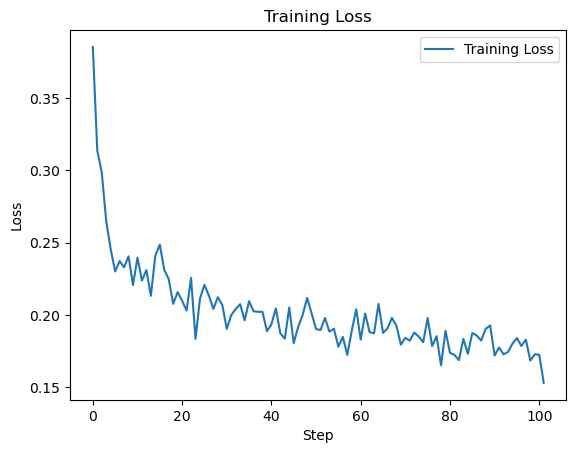

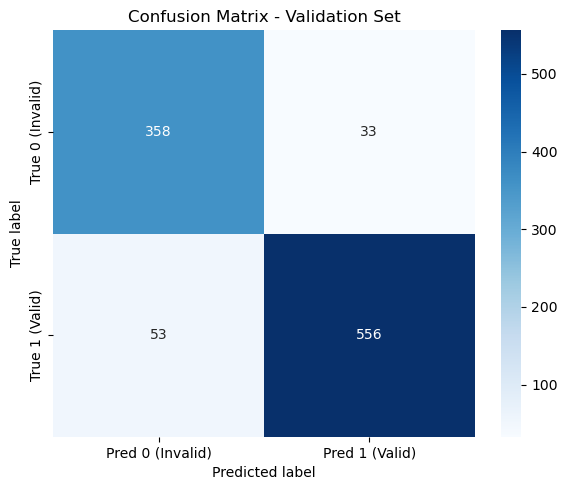

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Subset
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

# -----------------------------
# 6) Validation metrics and confusion matrix
# -----------------------------

offset = 20000
max_eval_samples = 1000

if max_eval_samples:
    eval_subset = Subset(
        val_dataset.dataset,
        val_dataset.indices[offset : offset + max_eval_samples],
    )
else:
    eval_subset = val_dataset

pred_output = trainer.predict(eval_subset)

logits = pred_output.predictions.reshape(-1)
y_prob = 1 / (1 + np.exp(-logits))
y_pred = (y_prob >= 0.5).astype(int)
y_true = pred_output.label_ids.astype(int).reshape(-1)

cm = confusion_matrix(y_true, y_pred)

print("=== Validation Metrics ===")
print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred, zero_division=0):.4f}")
print(f"F1-score : {f1_score(y_true, y_pred, zero_division=0):.4f}")
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred 0 (Invalid)", "Pred 1 (Valid)"],
    yticklabels=["True 0 (Invalid)", "True 1 (Valid)"],
)
plt.title("Confusion Matrix - Validation Set")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

Sampled block 15795-15805: Accuracy = 1.0000
Sampled block 860-870: Accuracy = 0.9000
Sampled block 54886-54896: Accuracy = 1.0000
Sampled block 6265-6275: Accuracy = 0.9000
Sampled block 37194-37204: Accuracy = 1.0000
Sampled block 44131-44141: Accuracy = 0.8000
Sampled block 60263-60273: Accuracy = 0.9000
Sampled block 16023-16033: Accuracy = 0.9000
Sampled block 41090-41100: Accuracy = 1.0000
Sampled block 67221-67231: Accuracy = 0.7000
Sampled block 64820-64830: Accuracy = 1.0000
Sampled block 769-779: Accuracy = 0.7000
Sampled block 59735-59745: Accuracy = 0.9000
Sampled block 62955-62965: Accuracy = 0.9000
Sampled block 64925-64935: Accuracy = 1.0000
Sampled block 67969-67979: Accuracy = 1.0000
Sampled block 5311-5321: Accuracy = 0.7000
Sampled block 53707-53717: Accuracy = 0.8000
Sampled block 28693-28703: Accuracy = 1.0000
Sampled block 25658-25668: Accuracy = 0.8000
Sampled block 18431-18441: Accuracy = 1.0000
Sampled block 2747-2757: Accuracy = 0.8000
Sampled block 59150-5916

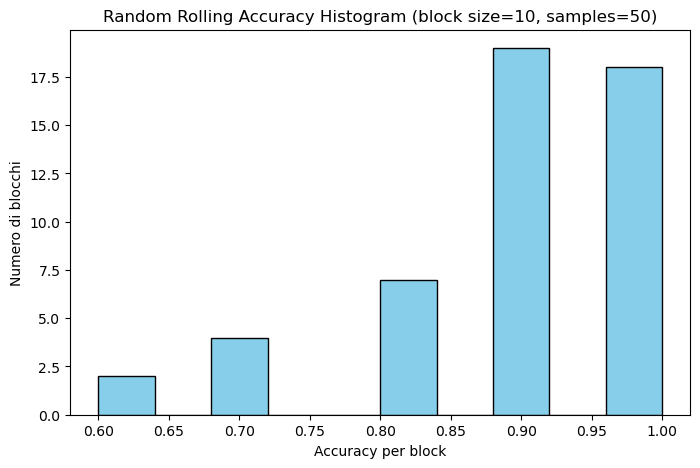

Media rolling accuracy : 0.8940
Std rolling accuracy   : 0.1085


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

# -----------------------------
# 7) Rolling random accuracy evaluation
# -----------------------------

block_size = 100
num_samples = 50
max_eval_samples = len(val_dataset)

eval_subset = Subset(val_dataset.dataset, val_dataset.indices[:max_eval_samples])
pred_output = trainer.predict(eval_subset)

logits = pred_output.predictions.reshape(-1)
y_prob = 1 / (1 + np.exp(-logits))
y_pred = (y_prob >= 0.5).astype(int)
y_true = pred_output.label_ids.astype(int).reshape(-1)

rolling_acc = []
for _ in range(num_samples):
    start_idx = np.random.randint(0, len(y_true) - block_size + 1)
    y_block_true = y_true[start_idx : start_idx + block_size]
    y_block_pred = y_pred[start_idx : start_idx + block_size]
    block_acc = accuracy_score(y_block_true, y_block_pred)
    rolling_acc.append(block_acc)
    print(f"Sampled block {start_idx}-{start_idx + block_size}: Accuracy = {block_acc:.4f}")

rolling_acc = np.array(rolling_acc)

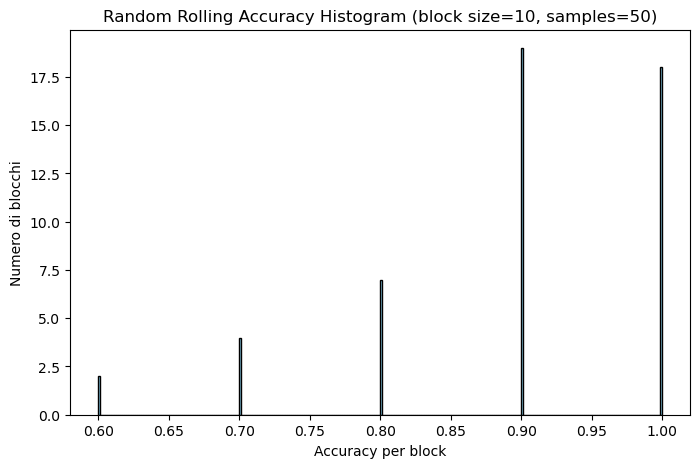

Media rolling accuracy : 0.8940
Std rolling accuracy   : 0.1085


In [ ]:
# -----------------------------
# 8) Rolling accuracy distribution
# -----------------------------

plt.figure(figsize=(8, 5))
plt.hist(rolling_acc, bins=300, color="skyblue", edgecolor="black")
plt.xlabel("Accuracy per block")
plt.ylabel("Number of blocks")
plt.title(f"Random rolling accuracy histogram (block size={block_size}, samples={num_samples})")
plt.show()

print(f"Mean rolling accuracy: {rolling_acc.mean():.4f}")
print(f"Std rolling accuracy : {rolling_acc.std():.4f}")